# Fig. 4 - 10D Embedded Leslie (contraction)

Replay of the 10D embedded-Leslie experiment used to illustrate that a
low-dimensional latent map can recover the bistable Morse graph of the
ambient system. We load the trained autoencoder from
`output/leslie_contraction/seed_0/` and re-render the Morse graph and
Morse sets from the saved DOT/CSV artifacts.

No CMGDB or training is invoked.

In [1]:
import os
os.environ.setdefault('MPLBACKEND', 'module://matplotlib_inline.backend_inline')
%matplotlib inline

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Image, display
from latentdynamics.config import load_config
from latentdynamics.training import load_any_checkpoint
from latentdynamics.viz import render_morse_from_files

REPO_ROOT = Path.cwd().resolve().parent  # code/
RENDER_ROOT = Path.cwd() / 'rendered'
RENDER_ROOT.mkdir(exist_ok=True)

DEVICE = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cuda') if torch.cuda.is_available()
    else torch.device('cpu')
)
print('device:', DEVICE)

device: mps


In [2]:
def _seed_dir(cfg, seed):
    return REPO_ROOT / cfg.paths.output_dir / f'seed_{seed}'

def _scaler_dir(cfg, train_file='train'):
    return REPO_ROOT / cfg.paths.output_dir / 'scalers' / train_file

def _bounds_from_log(path):
    if not path.exists():
        return None, None
    lower = upper = None
    for line in path.read_text().splitlines():
        k = line.split(':', 1)[0].strip().lower()
        if k == 'lower bounds':
            lower = json.loads(line.split(':', 1)[1])
        elif k == 'upper bounds':
            upper = json.loads(line.split(':', 1)[1])
    return lower, upper

def show(path, width=600):
    display(Image(filename=str(path), width=width))

def load_replay(cfg, seed, train_file='train'):
    seed_dir = _seed_dir(cfg, seed)
    if not seed_dir.exists():
        raise FileNotFoundError(seed_dir)
    model, arch = load_any_checkpoint(seed_dir / 'models', arch=cfg.arch, map_location=DEVICE)
    model.to(DEVICE).eval()
    scaler_path = _scaler_dir(cfg, train_file) / 'scaler.gz'
    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    return seed_dir, model, arch, scaler

@torch.no_grad()
def encode_batch(model, scaler, x_high):
    x = scaler.transform(x_high) if scaler is not None else x_high
    return model.encoder(torch.as_tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()

@torch.no_grad()
def advance_latent(model, z_low):
    z = torch.as_tensor(z_low, dtype=torch.float32, device=DEVICE)
    return model.latent_map(z).cpu().numpy()

## Config and artifacts

In [3]:
cfg = load_config(REPO_ROOT / 'configs' / 'leslie_contraction.yaml')
SEED = cfg.seeds[0]
seed_dir, model, arch, scaler = load_replay(cfg, SEED)
print('seed_dir:', seed_dir)
print(f'arch: high_dims={arch.high_dims}, low_dims={arch.low_dims}')

seed_dir: /Users/bdoprad/Work/Projects/latent-dynamics/code/output/leslie_contraction/seed_0
arch: high_dims=10, low_dims=2


## Encoded training data in latent space

train pairs: 160000, high_dims=10


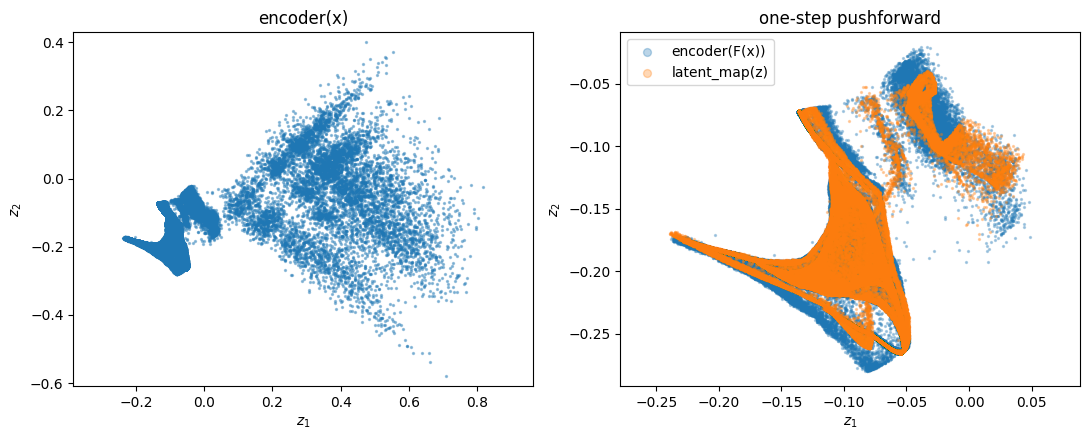

In [4]:
train_df = pd.read_csv(REPO_ROOT / cfg.paths.data_dir / 'train.csv')
high_cols = [c for c in train_df.columns if c.startswith('x')]
next_cols = [c for c in train_df.columns if c.startswith('y')]
x_high = train_df[high_cols].to_numpy()
y_high = train_df[next_cols].to_numpy()
print(f'train pairs: {x_high.shape[0]}, high_dims={x_high.shape[1]}')

z = encode_batch(model, scaler, x_high)
z_next = encode_batch(model, scaler, y_high)
z_pred = advance_latent(model, z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(z[:, 0], z[:, 1], s=2, alpha=0.4)
axes[0].set_title('encoder(x)')
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].set_aspect('equal', adjustable='datalim')
axes[1].scatter(z_next[:, 0], z_next[:, 1], s=2, alpha=0.3, label='encoder(F(x))')
axes[1].scatter(z_pred[:, 0], z_pred[:, 1], s=2, alpha=0.3, label='latent_map(z)')
axes[1].legend(loc='best', markerscale=4)
axes[1].set_title('one-step pushforward')
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')
axes[1].set_aspect('equal', adjustable='datalim')
plt.tight_layout(); plt.show()

## Re-rendered Morse graph and Morse sets

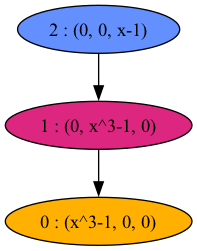

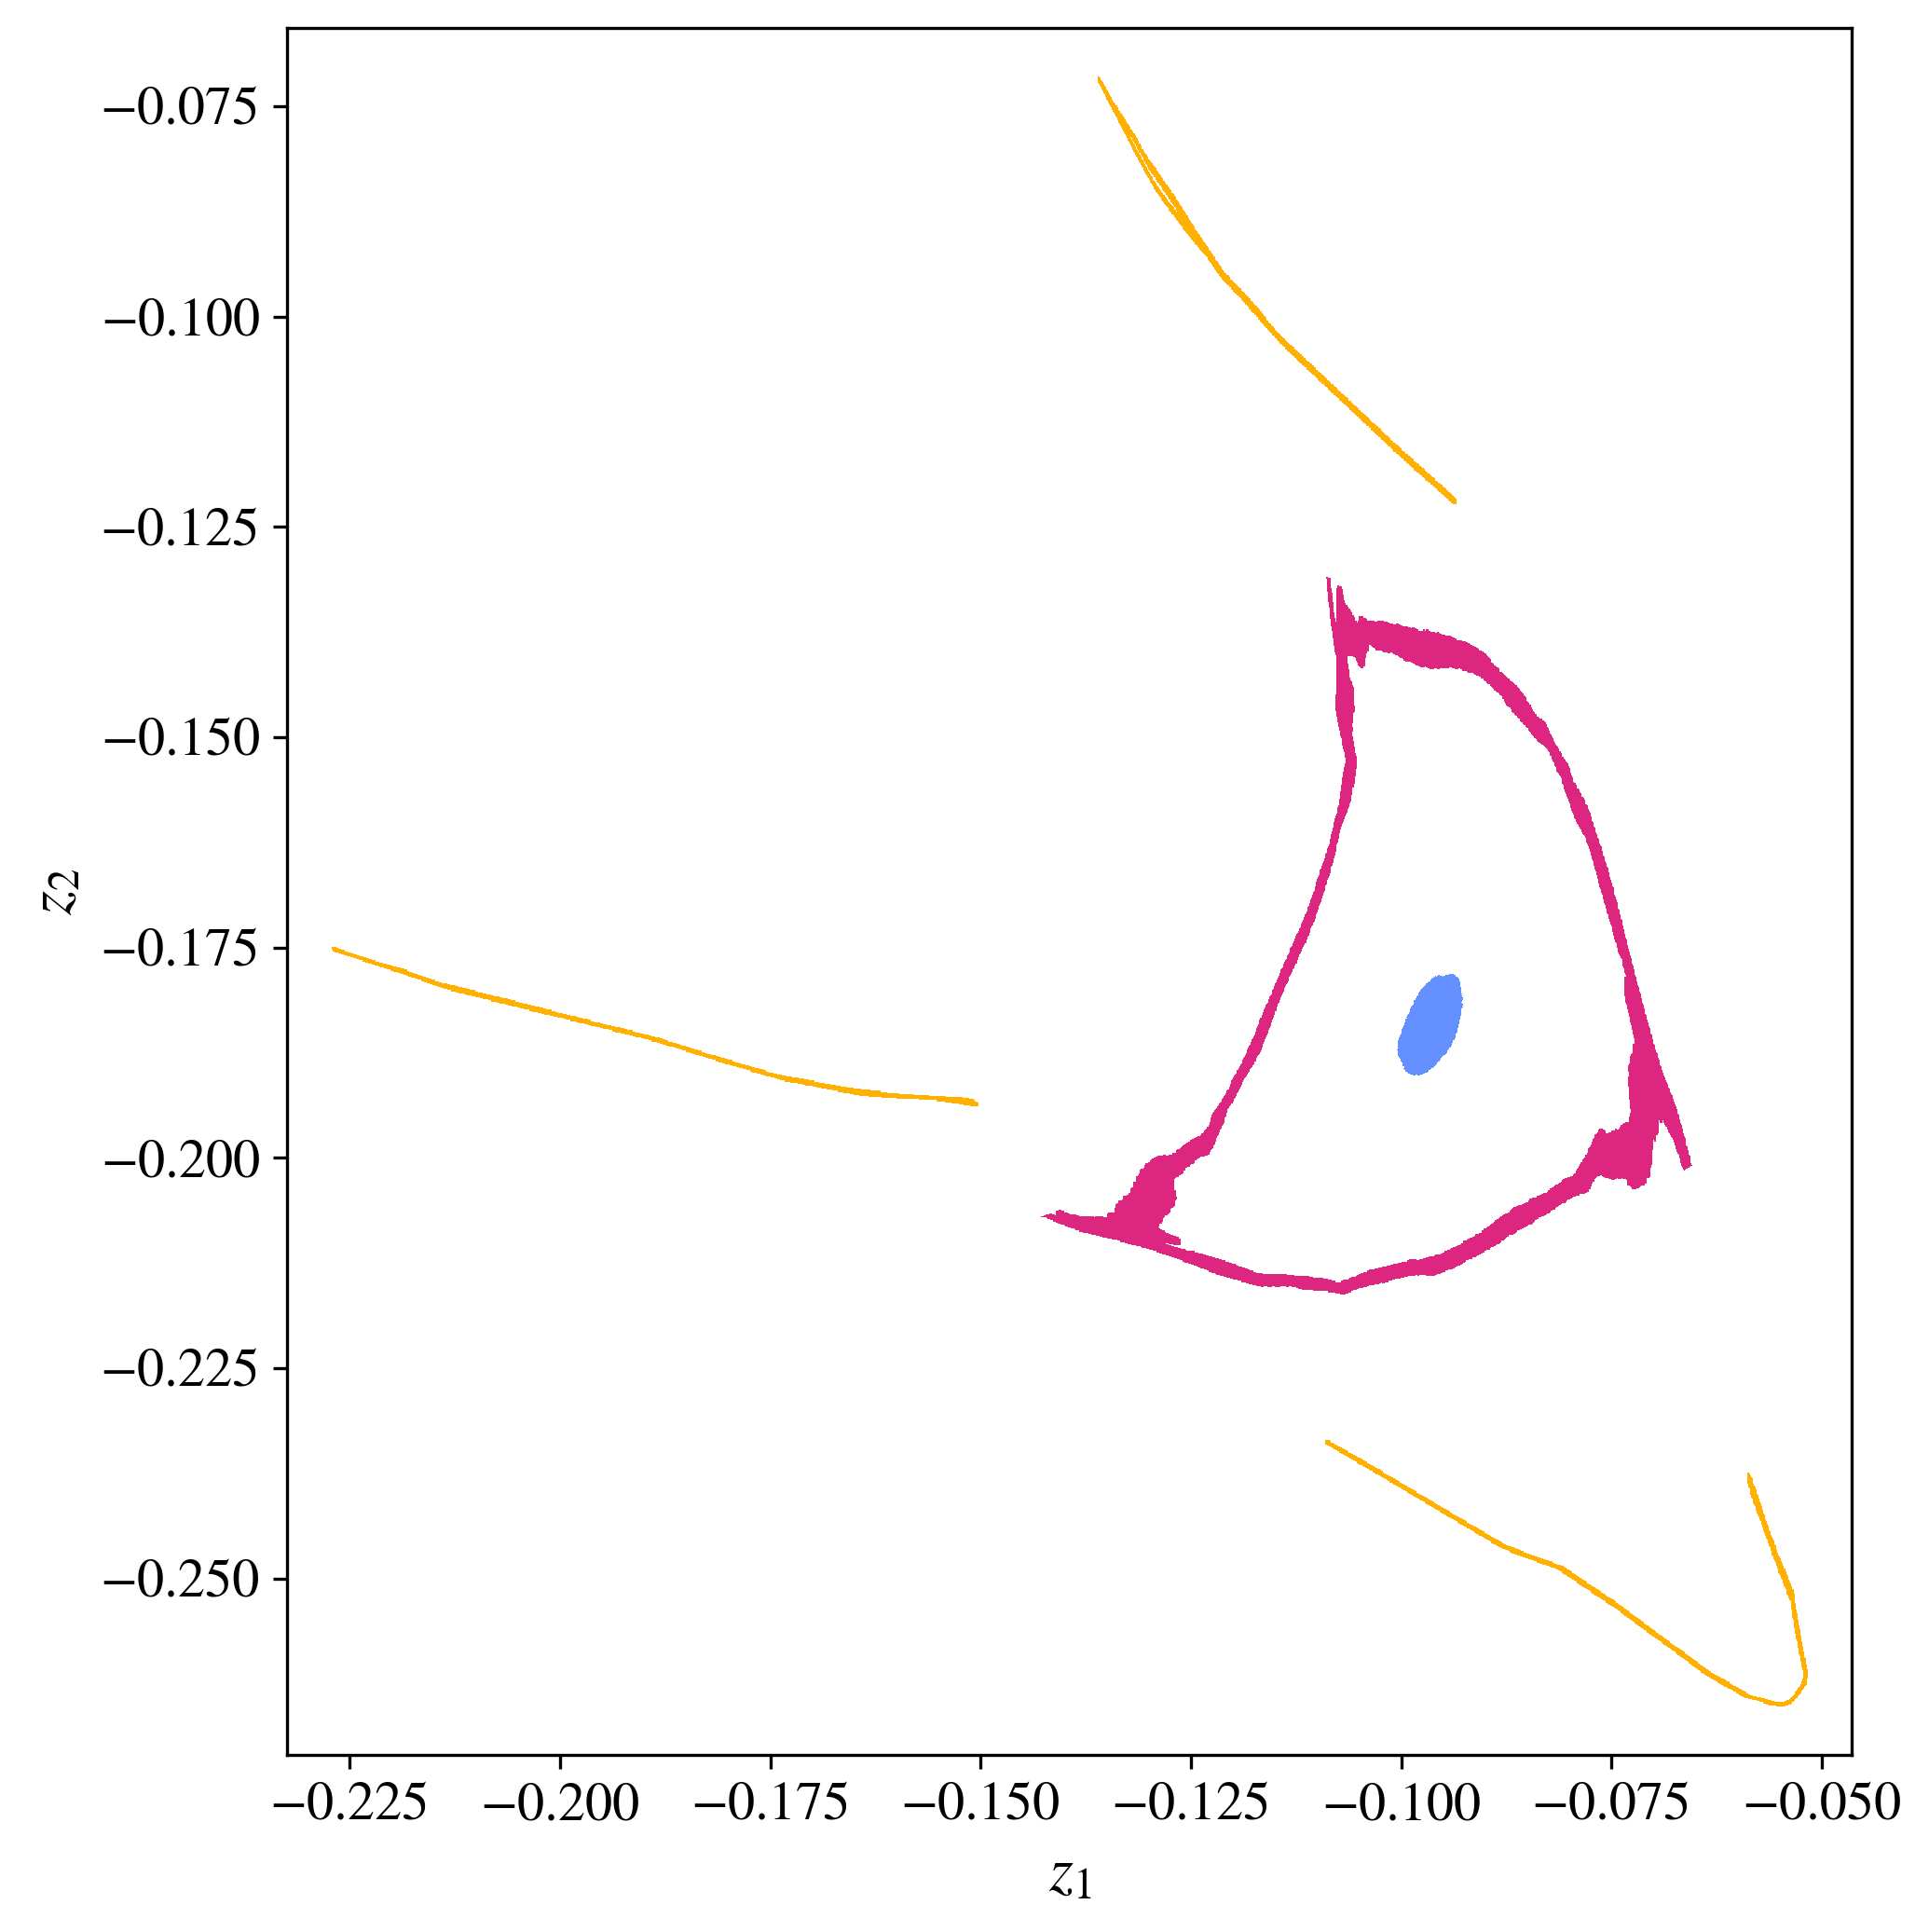

In [5]:
lower, upper = _bounds_from_log(seed_dir / 'mg_params_log.txt')
render_dir = RENDER_ROOT / 'leslie_contraction'
figs = render_morse_from_files(seed_dir / 'MG', bounds_lower=lower, bounds_upper=upper, out_dir=render_dir)
show(figs.morse_graph_png)
for p in figs.morse_sets_paths:
    if p.suffix == '.png':
        show(p, width=720)

## Diagnostics

Final losses, Morse-graph parameters, and any system-specific metrics
from the saved artifacts.

In [6]:
print('-- final_losses.txt --')
print((seed_dir / 'final_losses.txt').read_text())
print('-- mg_params_log.txt --')
print((seed_dir / 'mg_params_log.txt').read_text())
metrics = json.loads((seed_dir / 'metrics.json').read_text() or '{}')
print('-- metrics.json --')
print(json.dumps(metrics, indent=2) if metrics else '(empty)')

-- final_losses.txt --
best_epoch: 170
val_loss_ae1: 2.917641e-03
val_loss_ae2: 4.094924e-04
val_loss_dyn: 1.237544e-05
val_loss_total: 2.961065e-01

-- mg_params_log.txt --
Lower bounds: [-0.2484593391418457, -0.59046870470047]
Upper bounds: [0.8288848996162415, 0.41008657217025757]
subdiv_init: 25
subdiv_min: 27
subdiv_max: 28
subdiv_limit: 10000
bounds_epsilon_frac: 0.01
padding: True
box_map_backend: auto
bounds_source: encoded_data
duration_minutes: 16.1767

-- metrics.json --
(empty)
